# 02 — Phase 1 audit
Answers the Phase 1 report items A1–C2 using the training and test tables built in `01_build_dataset.ipynb`. All figures are saved to `figures/` at 300 DPI.

## A1. Dataset dimensions (initial shape)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

ROOT = Path(os.getcwd())
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROC = ROOT / "data" / "processed"
FIG = ROOT / "figures"

train = pd.read_csv(PROC / "train_w1_w2_raw.csv")
test  = pd.read_csv(PROC / "test_w2_w3_raw.csv")

ID_COLS = ["FPrimary", "hhmid", "district_id", "eacode", "hhweight3"]
TARGET = "dropout"
FEATURES = [c for c in train.columns if c not in ID_COLS + [TARGET]]

summary = pd.DataFrame({
    "Table": ["Training (Wave 1 → Wave 2)", "Test (Wave 2 → Wave 3)"],
    "N (rows)": [len(train), len(test)],
    "Total columns": [train.shape[1], test.shape[1]],
    "P (features)": [len(FEATURES)] * 2,
    "ID / grouping columns": [len(ID_COLS)] * 2,
    "Target columns": [1, 1],
    "Households": [train["FPrimary"].nunique(), test["FPrimary"].nunique()],
    "Districts": [train["district_id"].nunique(), test["district_id"].nunique()],
})
print(summary.to_string(index=False))

                     Table  N (rows)  Total columns  P (features)  ID / grouping columns  Target columns  Households  Districts
Training (Wave 1 → Wave 2)      1307             39            33                      5               1        1014        136
    Test (Wave 2 → Wave 3)      1395             39            33                      5               1        1091        137


## A2. Variable inventory (data types)
Every column classified by its statistical type (meaning of the values), not by its storage type. Saved to `phase1_strategy/A2_variable_inventory.csv` for the report.

In [2]:
# Statistical type of every column (what the values MEAN, not how pandas stores them)
VAR_TYPES = {
    # ---- Continuous: real-valued measurements
    "attend_hours":        ("Continuous", "Class hours attended in the last week"),
    "missed_hours":        ("Continuous", "Class hours missed in the last week"),
    "travel_minutes":      ("Continuous", "Daily round-trip travel time to school (min)"),
    "school_spend":        ("Continuous", "Spending on the child's schooling, last 12 months (cedis)"),
    "durables_value":      ("Continuous", "Total value of household durable goods (cedis)"),
    "persons_per_room":    ("Continuous", "Household size / number of rooms"),
    # ---- Discrete: counts and test scores
    "age":                 ("Discrete", "Age in completed years (8-13)"),
    "over_age":            ("Discrete", "Years older than official age for grade (can be negative)"),
    "math_score":          ("Discrete", "Math items correct (0-8)"),
    "english_score":       ("Discrete", "English reading items correct (0-7)"),
    "teacher_absent_days": ("Discrete", "Days per month the main teacher is absent"),
    "hh_size":             ("Discrete", "Number of household members"),
    "asset_count":         ("Discrete", "Number of 10 listed assets owned (0-10)"),
    "rooms":               ("Discrete", "Number of rooms in dwelling"),
    # ---- Ordinal categorical: ordered levels
    "grade_level":         ("Ordinal", "Current grade: 0 preschool, 1-6 P1-P6, 7-9 JSS1-3"),
    "father_edu":          ("Ordinal", "Father's education: 0 none ... 4 post-secondary"),
    "mother_edu":          ("Ordinal", "Mother's education: 0 none ... 4 post-secondary"),
    "has_textbooks":       ("Ordinal", "Textbooks: 1 all, 2 some, 3 none (reversed order)"),
    # ---- Nominal categorical: unordered labels
    "regioncode":          ("Nominal", "Region of Ghana (10 regions)"),
    "school_type":         ("Nominal", "Public/private x religious/non-religious (4)"),
    "relationship_to_head":("Nominal", "Child, grandchild, other relative, foster, non-relative"),
    "math_status":         ("Nominal", "Math test: scored / blank_sheet / not_tested"),
    "english_status":      ("Nominal", "English test: scored / blank_sheet / not_tested"),
    # ---- Binary (nominal with 2 levels)
    "sex":                 ("Binary", "1 male, 2 female"),
    "urbrur":              ("Binary", "1 urban, 2 rural"),
    "on_vacation":         ("Binary", "Interviewed during a school holiday week"),
    "feeding_program":     ("Binary", "1 in school feeding programme, 2 not"),
    "father_alive":        ("Binary", "Father alive"),
    "mother_alive":        ("Binary", "Mother alive"),
    "father_in_hh":        ("Binary", "Father lives in the household"),
    "mother_in_hh":        ("Binary", "Mother lives in the household"),
    "orphan":              ("Binary", "At least one parent deceased"),
    "electricity":         ("Binary", "Main lighting is mains electricity"),
    # ---- Not features
    "FPrimary":            ("Identifier", "Household ID"),
    "hhmid":               ("Identifier", "Member ID within household"),
    "district_id":         ("Identifier / grouping", "District (region x district code) - for grouped CV"),
    "eacode":              ("Identifier / grouping", "Enumeration area"),
    "hhweight3":           ("Survey weight", "Wave 1 household sampling weight"),
    "dropout":             ("Target (binary)", "1 dropout, 0 still enrolled"),
}
assert set(VAR_TYPES) == set(train.columns), set(train.columns) ^ set(VAR_TYPES)

def describe_values(s):
    s = s.dropna()
    if not pd.api.types.is_numeric_dtype(s):
        return ", ".join(sorted(s.unique().astype(str)))
    if s.nunique() <= 10:
        return ", ".join(str(int(v)) if float(v).is_integer() else str(v) for v in sorted(s.unique()))
    return f"{s.min():g} to {s.max():g}"

inventory = pd.DataFrame([
    {"Variable": c, "Statistical type": t, "Description": d,
     "Stored as": str(train[c].dtype), "Unique values (train)": train[c].nunique(),
     "Values / range (train)": describe_values(train[c])}
    for c, (t, d) in VAR_TYPES.items()])

print(inventory["Statistical type"].value_counts().to_string(), "\n")
print("Datetime / text features: none (interview dates exist in the raw files but are not features)\n")
print(inventory[["Variable", "Statistical type", "Stored as", "Unique values (train)", "Values / range (train)"]].to_string(index=False))
inventory.to_csv(ROOT / "phase1_strategy" / "A2_variable_inventory.csv", index=False)

Statistical type
Binary                   10
Discrete                  8
Continuous                6
Nominal                   5
Ordinal                   4
Identifier                2
Identifier / grouping     2
Survey weight             1
Target (binary)           1 

Datetime / text features: none (interview dates exist in the raw files but are not features)

            Variable      Statistical type Stored as  Unique values (train)          Values / range (train)
        attend_hours            Continuous   float64                     68                         0 to 50
        missed_hours            Continuous   float64                     37                         0 to 49
      travel_minutes            Continuous   float64                     36                        0 to 300
        school_spend            Continuous   float64                    633                       0 to 6500
      durables_value            Continuous   float64                    817                    

## A3. Baseline missingness (before any imputation)
Measured after the rule-based corrections (sentinel codes and impossible values already converted to missing). Figure 1.1 shows the pattern; white = missing.

(a) Missing values per feature (features with no missing values not shown):
                      Train: missing (n)  Train: missing (%)  Test: missing (n)  Test: missing (%)
missed_hours                        1017                77.8                163               11.7
teacher_absent_days                  743                56.8                444               31.8
english_score                        716                54.8                557               39.9
math_score                           437                33.4                340               24.4
attend_hours                         285                21.8                163               11.7
father_edu                           101                 7.7                 75                5.4
school_type                           84                 6.4                  0                0.0
grade_level                           81                 6.2                  7                0.5
over_age                         

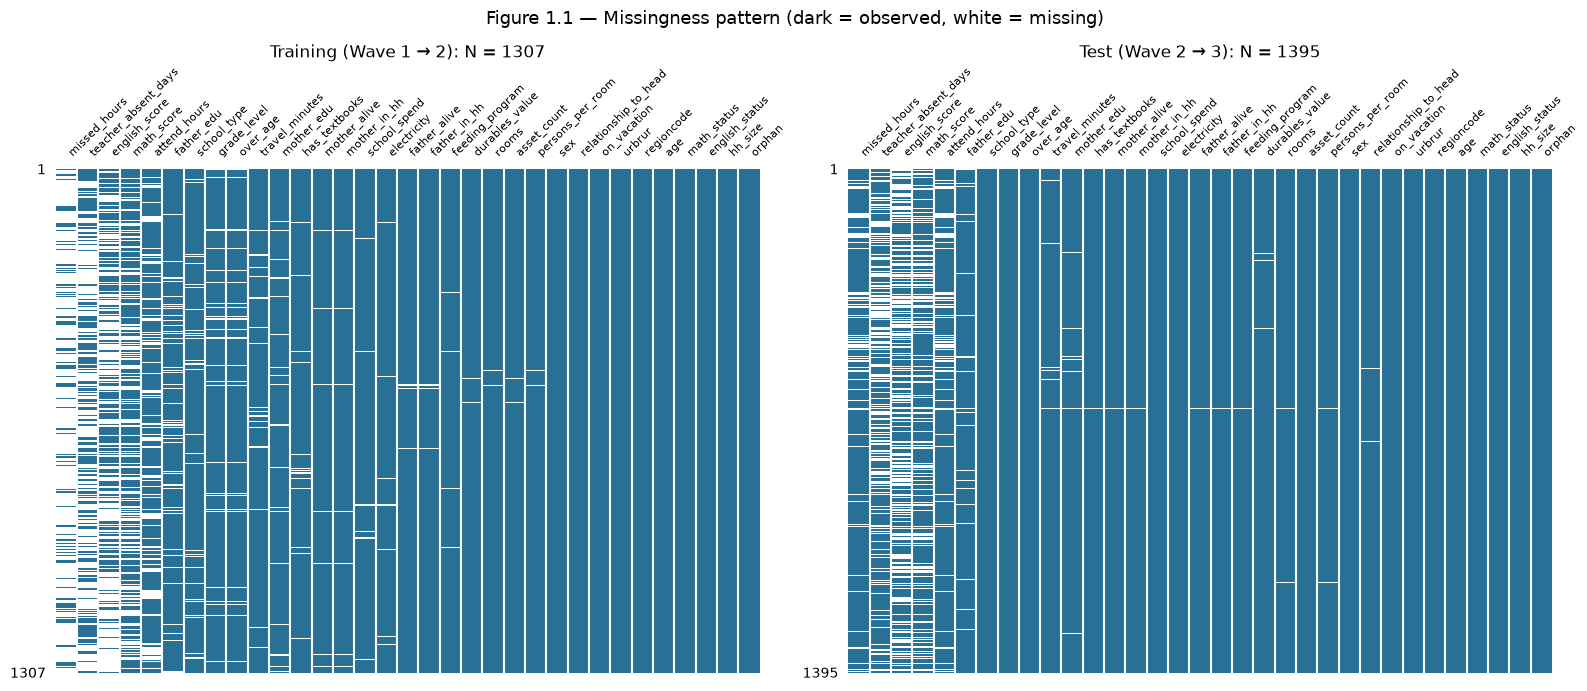

In [3]:
import matplotlib.pyplot as plt
import missingno as msno

def missing_table(df, name):
    m = df[FEATURES].isna()
    return pd.DataFrame({f"{name}: missing (n)": m.sum(), f"{name}: missing (%)": (m.mean() * 100).round(1)})

miss = pd.concat([missing_table(train, "Train"), missing_table(test, "Test")], axis=1)
miss = miss.sort_values("Train: missing (%)", ascending=False)
print("(a) Missing values per feature (features with no missing values not shown):")
print(miss[(miss["Train: missing (n)"] > 0) | (miss["Test: missing (n)"] > 0)].to_string())

for name, df in [("Train", train), ("Test", test)]:
    m = df[FEATURES].isna()
    complete = (~m.any(axis=1)).sum()
    print(f"\n{name}:")
    print(f"  (b) Overall missing: {m.values.sum()} of {m.size} feature cells = {m.values.mean() * 100:.2f}%")
    print(f"  (c) Complete rows: {complete} ({complete / len(df) * 100:.1f}%) | rows with >= 1 missing: {len(df) - complete} ({(len(df) - complete) / len(df) * 100:.1f}%)")
    print(f"      Features with no missing values: {(m.sum() == 0).sum()} of {len(FEATURES)}")

miss.to_csv(ROOT / "phase1_strategy" / "A3_missingness.csv")

# Figure 1.1: missingness matrix (white = missing), features ordered from most to least missing
order = miss.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (name, df) in zip(axes, [("Training (Wave 1 → 2)", train), ("Test (Wave 2 → 3)", test)]):
    msno.matrix(df[order], ax=ax, sparkline=False, fontsize=8, color=(0.16, 0.44, 0.59))
    ax.set_title(f"{name}: N = {len(df)}", fontsize=12)
plt.suptitle("Figure 1.1 — Missingness pattern (dark = observed, white = missing)", fontsize=13)
plt.tight_layout()
plt.savefig(FIG / "fig1_1_missingness_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## A4. Target label (Y): binary classification
`dropout` = 1 if the child is out of school at the next wave without having completed basic education (JSS3), 0 if still enrolled. Figure 1.2 shows the class balance.

                Table  Enrolled (Y=0)  Dropout (Y=1)  Dropout rate (%) Imbalance ratio (0:1)  Class weight for Y=1 (n0/n1)
Training (Wave 1 → 2)            1119            188              14.4              5.95 : 1                          5.95
    Test (Wave 2 → 3)            1250            145              10.4              8.62 : 1                          8.62


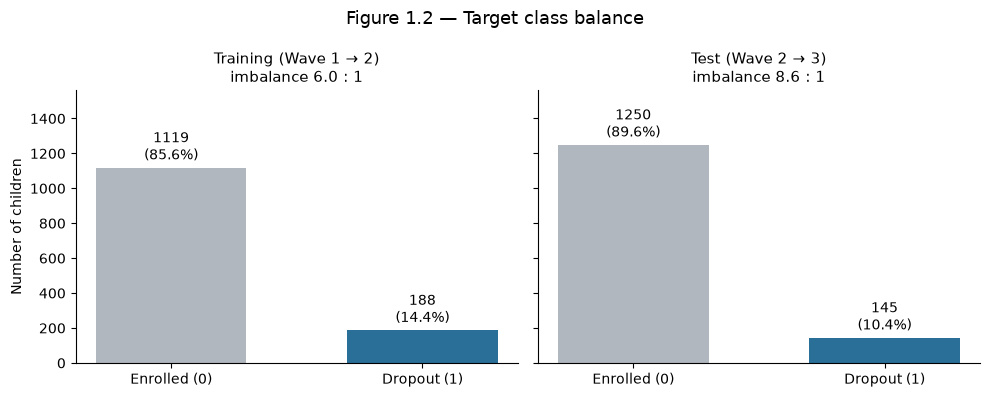

In [4]:
rows = []
for name, df in [("Training (Wave 1 → 2)", train), ("Test (Wave 2 → 3)", test)]:
    n1 = int(df[TARGET].sum()); n0 = len(df) - n1
    rows.append({"Table": name, "Enrolled (Y=0)": n0, "Dropout (Y=1)": n1,
                 "Dropout rate (%)": round(n1 / len(df) * 100, 1),
                 "Imbalance ratio (0:1)": f"{n0 / n1:.2f} : 1",
                 "Class weight for Y=1 (n0/n1)": round(n0 / n1, 2)})
target_summary = pd.DataFrame(rows)
print(target_summary.to_string(index=False))
target_summary.to_csv(ROOT / "phase1_strategy" / "A4_target.csv", index=False)

# Figure 1.2: class balance bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (name, df) in zip(axes, [("Training (Wave 1 → 2)", train), ("Test (Wave 2 → 3)", test)]):
    counts = df[TARGET].value_counts().reindex([0, 1])
    bars = ax.bar(["Enrolled (0)", "Dropout (1)"], counts.values, color=["#b0b7bf", "#2a6f97"], width=0.6)
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 20, f"{v}\n({v / len(df) * 100:.1f}%)", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"{name}\nimbalance {counts[0] / counts[1]:.1f} : 1", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Number of children")
axes[0].set_ylim(0, max(len(train), len(test)) * 1.12)
plt.suptitle("Figure 1.2 — Target class balance", fontsize=13)
plt.tight_layout()
plt.savefig(FIG / "fig1_2_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## B1. Missingness mechanisms
### B1.1 Evidence: what is missingness related to?
For each feature with missing values (training table): dropout rate when missing vs observed (χ² test), and whether missingness differs by age, sex, urban/rural, northern regions, asset count and mother's presence (Mann-Whitney / χ², p < 0.05). Skewness of the observed values guides the imputation choice in B1.2.

In [5]:
from scipy import stats

COVARIATES = {"age": "num", "sex": "cat", "urbrur": "cat", "north": "cat", "asset_count": "num", "mother_in_hh": "cat"}
tr = train.assign(north=train["regioncode"].isin([8, 9, 10]).astype(int))   # Northern, Upper East, Upper West

def p_value(miss, x, kind):
    ok = x.notna()
    miss, x = miss[ok], x[ok]
    if miss.sum() < 5 or (~miss).sum() < 5:
        return np.nan
    if kind == "num":
        return stats.mannwhitneyu(x[miss], x[~miss]).pvalue
    return stats.chi2_contingency(pd.crosstab(miss, x))[1]

rows = []
for c in FEATURES:
    miss = tr[c].isna()
    if miss.sum() == 0:
        continue
    row = {"feature": c, "missing %": round(miss.mean() * 100, 1),
           "dropout | missing": round(tr.loc[miss, TARGET].mean(), 3),
           "dropout | observed": round(tr.loc[~miss, TARGET].mean(), 3),
           "p (missing vs Y)": p_value(miss, tr[TARGET], "cat")}
    related = []
    for cov, kind in COVARIATES.items():
        if cov == c:
            continue
        p = p_value(miss, tr[cov], kind)
        if p < 0.05:
            diff = tr.loc[miss, cov].mean() - tr.loc[~miss, cov].mean()
            related.append(f"{cov}({'+' if diff > 0 else '-'})")
    row["missingness related to (p<0.05)"] = ", ".join(related) if related else "none"
    if pd.api.types.is_numeric_dtype(tr[c]):
        row["skewness (observed)"] = round(tr[c].skew(), 2)
    rows.append(row)

b1_evidence = pd.DataFrame(rows).sort_values("missing %", ascending=False)
b1_evidence["p (missing vs Y)"] = b1_evidence["p (missing vs Y)"].map(lambda p: "n<5" if pd.isna(p) else f"{p:.3f}")
print(b1_evidence.to_string(index=False))
b1_evidence.to_csv(ROOT / "phase1_strategy" / "B1_missingness_evidence.csv", index=False)
print("\n(+) = higher among children with the value missing; (-) = lower. north = Northern/Upper East/Upper West regions.")

            feature  missing %  dropout | missing  dropout | observed p (missing vs Y)                      missingness related to (p<0.05)  skewness (observed)
       missed_hours       77.8              0.142               0.152            0.735                            north(-), mother_in_hh(-)                 1.93
teacher_absent_days       56.8              0.172               0.106            0.001          age(+), urbrur(-), north(+), asset_count(+)                 2.95
      english_score       54.8              0.155               0.130            0.234          age(-), urbrur(+), north(+), asset_count(-)                -0.32
         math_score       33.4              0.160               0.136            0.267                                     age(-), north(+)                -0.14
       attend_hours       21.8              0.168               0.137            0.214                                             north(+)                -0.96
         father_edu        7.7    

### B1.2 Mechanism diagnosis and imputation plan
Rules: numeric |skew| < 0.5 → mean; |skew| ≥ 0.5 → median; binary/ordinal → mode; nominal with informative missingness → "missing" category; indicator flag when missingness is structural, MNAR or related to Y. KNN (k=5) for grade level. All imputers are fitted on X_train only, inside each CV fold (Phase 2 pipeline). Listwise deletion is rejected: only 4.1% of rows are complete.

In [6]:
# Decision rules (applied consistently):
#   numeric, |skewness| < 0.5  -> mean   (near-symmetric: mean is unbiased and efficient)
#   numeric, |skewness| >= 0.5 -> median (robust to the long tail)
#   binary / ordinal           -> mode   (keeps a valid category)
#   nominal with informative missingness -> explicit "missing" category
#   + missing-indicator flag when missingness is structural, MNAR, or related to Y (p < 0.05)
# Every imputer is fitted on X_train only (inside the Phase 2 pipeline, re-fitted in each CV fold).
B1_DECISIONS = {
    "missed_hours": ("MAR (recording practice; varies by region). Blank = 0 hours missed",
        "Rule: 0 when attendance was recorded; remaining (vacation / attendance unknown) -> median",
        "W1 recorded >0 for 17.8% vs 14.4% in tablet-based W2; unrelated to Y (p=0.74); skew 1.93"),
    "teacher_absent_days": ("Structural (asked only if one main teacher) - informative",
        "Median (= 0) + indicator teacher_absent_missing",
        "Missingness predicts dropout (17.2% vs 10.6%, p=0.001); skew 2.95"),
    "english_score": ("MAR on age/region/wealth (not tested < 9 by design) + MNAR blank sheets",
        "Mean + keep english_status category (scored / blank_sheet / not_tested)",
        "Related to age, urban, north, assets; skew -0.32 -> mean; blank sheet = likely cannot read"),
    "math_score": ("MAR on age/region (not tested < 9 by design) + MNAR blank sheets",
        "Mean + keep math_status category",
        "Related to age, north; skew -0.14 -> mean; blank sheet dropout 36% vs 14%"),
    "attend_hours": ("Structural (school holiday) + MAR on region",
        "Median + on_vacation flag (already exists) + indicator attend_missing",
        "Related to north; skew -0.96 -> median"),
    "father_edu": ("MAR ('don't know' about an absent father)",
        "Mode + indicator father_edu_missing ('not reported', as in proposal)",
        "Related to urban, north, assets, mother presence; ordinal"),
    "school_type": ("MAR on region", "Constant category 'missing' (one-hot)",
        "Related to north; nominal; dropout 19.0% vs 14.1%"),
    "grade_level": ("MAR on region", "KNN (k=5) on age, sex, urban, region, asset_count",
        "Grade is strongly tied to age (rho 0.64) -> neighbours give a better estimate than one global value"),
    "over_age": ("MAR (missing exactly when grade is missing)", "Recomputed from the KNN-imputed grade",
        "over_age = age - grade_level - 5"),
    "travel_minutes": ("MAR on region / mother presence", "Median", "skew 3.15"),
    "mother_edu": ("MAR ('don't know' about an absent mother)", "Mode + indicator mother_edu_missing",
        "Related to urban, assets, mother presence; ordinal"),
    "has_textbooks": ("Consistent with MCAR", "Mode", "Unrelated to Y and covariates; ordinal"),
    "school_spend": ("MAR on age / urban / wealth", "Median", "skew 10.78"),
    "mother_in_hh": ("Consistent with MCAR", "Mode", "Binary; n missing = 20"),
    "mother_alive": ("Consistent with MCAR", "Mode", "Binary; n missing = 20"),
    "electricity": ("Possibly MAR (small n)", "Mode", "Binary; n missing = 17; p=0.034 but too few for an indicator"),
    "father_alive": ("MAR on urban / mother presence", "Mode", "Binary; n missing = 14"),
    "father_in_hh": ("MAR on urban / mother presence", "Mode", "Binary; n missing = 14"),
    "feeding_program": ("Consistent with MCAR", "Mode", "Binary; n missing = 11"),
    "asset_count": ("Consistent with MCAR", "Median", "skew 0.62"),
    "durables_value": ("Consistent with MCAR", "Median", "skew 10.05"),
    "rooms": ("Consistent with MCAR (household file not matched)", "Median", "skew 4.82"),
    "persons_per_room": ("Consistent with MCAR", "Recomputed from imputed rooms", "hh_size / rooms"),
    "relationship_to_head": ("Invalid code set to missing (test only, n=3)", "Mode", "Nominal"),
}
b1_plan = (b1_evidence.set_index("feature")[["missing %", "p (missing vs Y)", "skewness (observed)"]]
           .join(pd.DataFrame.from_dict(B1_DECISIONS, orient="index",
                                        columns=["Mechanism", "Treatment", "Evidence / justification"]), how="outer"))
b1_plan["missing %"] = b1_plan["missing %"].fillna(0.0)   # relationship_to_head: missing only in test
b1_plan = b1_plan.sort_values("missing %", ascending=False)
print(b1_plan[["missing %", "Mechanism", "Treatment"]].to_string())
b1_plan.to_csv(ROOT / "phase1_strategy" / "B1_mechanism_and_imputation_plan.csv")

                      missing %                                                                Mechanism                                                                                  Treatment
feature                                                                                                                                                                                            
missed_hours               77.8       MAR (recording practice; varies by region). Blank = 0 hours missed  Rule: 0 when attendance was recorded; remaining (vacation / attendance unknown) -> median
teacher_absent_days        56.8                Structural (asked only if one main teacher) - informative                                            Median (= 0) + indicator teacher_absent_missing
english_score              54.8  MAR on age/region/wealth (not tested < 9 by design) + MNAR blank sheets                    Mean + keep english_status category (scored / blank_sheet / not_tested)
math_score          